# Notebook principal de avances ENIGH 2018-2024

Este notebook concentra los principales hallazgos del proyecto en formato de avance escolar para tesina. La prioridad aqui es que el trabajo sea interpretable, visual y reproducible: cada tabla o grafica importante sale de los archivos intermedios ya generados

**Lectura rapida:** este archivo no reemplaza a los notebooks tecnicos. Funciona como una bitacora principal para explicar que se hizo, que evidencia hay y que decisiones faltan antes de pasar a modelado.

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "README.md").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("No pude localizar la raiz del proyecto.")


ROOT = find_project_root()
REV1 = ROOT / "data" / "interim" / "revision_1"
REV2 = ROOT / "data" / "interim" / "revision_2"
REV3 = ROOT / "data" / "interim" / "revision_3"
FIG_DIR = ROOT / "reports" / "figures" / "notebook_principal"
TABLE_DIR = ROOT / "reports" / "tables" / "notebook_principal"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

for path in [REV1, REV2, REV3]:
    assert path.exists(), f"Falta la carpeta esperada: {path}"

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

plt.rcParams.update({
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})

PALETTE = ["#2f6f9f", "#c44e52", "#55a868", "#8172b2", "#ccb974", "#64b5cd"]

print(f"Proyecto: {ROOT}")
print(f"Revision 1: {REV1.exists()} | Revision 2: {REV2.exists()} | Revision 3: {REV3.exists()}")

Proyecto: C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-income-modeling
Revision 1: True | Revision 2: True | Revision 3: True


In [2]:
def project_path(path_string):
    return ROOT / Path(str(path_string).replace("\\", "/"))


def format_int(value):
    if pd.isna(value):
        return ""
    return f"{int(round(float(value))):,}"


def format_pct(value, digits=1):
    if pd.isna(value):
        return ""
    return f"{float(value):,.{digits}f}%"


def format_money(value):
    if pd.isna(value):
        return ""
    return f"${float(value):,.0f}"


with open(REV2 / "resumen_revision_2.json", encoding="utf-8") as f:
    resumen_r2 = json.load(f)
with open(REV3 / "resumen_revision_3.json", encoding="utf-8") as f:
    resumen_r3 = json.load(f)

archivos_r3 = pd.read_csv(REV3 / "archivos_revision_3.csv")
cobertura_geo = pd.read_csv(REV2 / "validacion_cobertura_geografia.csv")
validacion_merge = pd.read_csv(REV2 / "validacion_merge_geografia.csv")
obs_mun = pd.read_csv(REV2 / "resumen_observaciones_por_municipio.csv")
matriz_estabilidad = pd.read_csv(REV3 / "matriz_estabilidad_categoricas.csv")
validacion_mappings = pd.read_csv(REV3 / "validacion_mappings_categoricas.csv")
muestra_prioritaria = pd.read_csv(REV3 / "muestra_poblacion_prioritaria.csv")
variables_manual = pd.read_csv(REV3 / "variables_revision_manual.csv")

print("Archivos de revision cargados.")

Archivos de revision cargados.


## 1. Resumen de avance

La lectura general es positiva: ya hay una base longitudinal comparable, se resolvieron problemas tecnicos de tipos y 2024, se integró geografía municipal donde la tabla lo permite, y ahora muchas variables categóricas tienen etiquetas legibles. Esto vuelve el proyecto mucho más defendible para una tesina porque separa cambios de encuesta, limpieza técnica e interpretación sustantiva.

In [3]:
resumen_avances = pd.DataFrame([
    {
        "etapa": "Revision 1",
        "foco": "EDA longitudinal inicial",
        "avance principal": "Se apilaron 2018, 2020, 2022 y 2024 usando columnas comparables.",
        "evidencia": "6 tablas comunes; 544 variables comparables documentadas en el reporte.",
    },
    {
        "etapa": "Revision 2",
        "foco": "Limpieza y geografia",
        "avance principal": "Se corrigieron tipos, artefactos de 2024 y se anadio geografia municipal.",
        "evidencia": "100% de match geografico en concentradohogar y viviendas; 0 filas perdidas.",
    },
    {
        "etapa": "Revision 3",
        "foco": "Decodificacion categorica",
        "avance principal": "Se extrajeron catalogos de los PDFs y se crearon columnas legibles *_desc.",
        "evidencia": "263 variables decodificadas; 0 codigos sin mapping dentro de variables decodificadas.",
    },
])

resumen_avances.to_csv(TABLE_DIR / "resumen_avances.csv", index=False, encoding="utf-8")
display(resumen_avances)

etapa,foco,avance principal,evidencia
Revisión 1,EDA longitudinal inicial,"Se apilaron 2018, 2020, 2022 y 2024 usando columnas comparables.",6 tablas comunes; 544 variables comparables documentadas en el reporte.
Revisión 2,Limpieza y geografía,"Se corrigieron tipos, artefactos de 2024 y se añadió geografía municipal.",100% de match geográfico en concentradohogar y viviendas; 0 filas perdidas.
Revisión 3,Decodificación categórica,Se extrajeron catálogos de los PDFs y se crearon columnas legibles *_desc.,263 variables decodificadas; 0 códigos sin mapping dentro de variables decodificadas.


In [4]:
metricas_clave = pd.DataFrame([
    ["Bases longitudinales disponibles", "6 tablas", "concentradohogar, hogares, ingresos, poblacion, trabajos y viviendas"],
    ["Variables comparables documentadas", "544", "conservadas en los cuatro levantamientos despues de homologar nombres"],
    ["Cobertura geografica minima", format_pct(resumen_r2["geografia"]["cobertura_match_min_pct"]), "merge por ubica_geo en concentradohogar y viviendas"],
    ["Municipios en catalogo deduplicado", format_int(resumen_r2["geografia"]["catalogo_municipal_filas"]), "sin duplicados ni conflictos"],
    ["Artefactos decimales en variables C", f"{format_int(resumen_r2['tipos']['variables_c_con_artificio_decimal_antes'])} -> {format_int(resumen_r2['tipos']['variables_c_con_artificio_decimal_despues'])}", "casos tipo 1.0 corregidos"],
    ["Celdas C con artefacto corregidas", format_int(resumen_r2["tipos"]["celdas_c_con_artificio_decimal_antes"]), "no quedan artefactos decimales despues de la limpieza"],
    ["Variables con mapping extraido", format_int(resumen_r3["variables_categoricas_detectadas"]), "catalogo maestro construido desde documentacion ENIGH"],
    ["Variables decodificadas", format_int(resumen_r3["variables_decodificadas"]), "columnas *_desc creadas para lectura sustantiva"],
    ["Codigos sin mapping en variables decodificadas", format_int(resumen_r3["codigos_observados_sin_mapping_en_decodificadas"]), "validacion interna satisfactoria"],
    ["Codigos pendientes en variables no decodificadas", format_int(resumen_r3["codigos_observados_sin_mapping_total"]), "principalmente anos de bienes, identificadores y lengua indigena 2018"],
], columns=["indicador", "valor", "lectura"])

metricas_clave.to_csv(TABLE_DIR / "metricas_clave.csv", index=False, encoding="utf-8")
display(metricas_clave)

indicador,valor,lectura
Bases longitudinales disponibles,6 tablas,"concentradohogar, hogares, ingresos, poblacion, trabajos y viviendas"
Variables comparables documentadas,544,conservadas en los cuatro levantamientos despues de homologar nombres
Cobertura geográfica mínima,100.0%,merge por ubica_geo en concentradohogar y viviendas
Municipios en catálogo deduplicado,"2,478",sin duplicados ni conflictos
Artefactos decimales en variables C,208 -> 0,casos tipo 1.0 corregidos en 2024 y otras tablas
Celdas C con artefacto corregidas,"11,875,227",no quedan artefactos decimales despues de la limpieza
Variables con mapping extraído,431,catálogo maestro construido desde documentación ENIGH
Variables decodificadas,263,columnas *_desc creadas para lectura sustantiva
Códigos sin mapping en variables decodificadas,0,validación interna satisfactoria
Códigos pendientes en variables no decodificadas,"6,393","principalmente años de bienes, identificadores y lengua indígena 2018"


## 2. Bases disponibles y tamaño de muestra

La primera pregunta de control es si las bases quedaron apiladas de forma consistente por año. La tabla y la gráfica siguientes usan las bases decodificadas de la revisión 3, que ya incorporan lo hecho en revisiones previas.

In [5]:
def count_rows_by_year(archivos):
    rows = []
    for _, row in archivos.iterrows():
        counts = {}
        path = project_path(row["archivo"])
        for chunk in pd.read_csv(path, usecols=["anio"], chunksize=250_000):
            vc = chunk["anio"].value_counts(dropna=False)
            for year, count in vc.items():
                counts[int(year)] = counts.get(int(year), 0) + int(count)
        for year, count in sorted(counts.items()):
            rows.append({"tabla": row["tabla"], "anio": year, "registros": count})
    return pd.DataFrame(rows)


conteos_anio = count_rows_by_year(archivos_r3)
conteos_anio.to_csv(TABLE_DIR / "conteos_por_tabla_anio.csv", index=False, encoding="utf-8")

conteos_tabla = conteos_anio.pivot(index="tabla", columns="anio", values="registros").reset_index()
conteos_tabla_display = conteos_tabla.copy()
for col in conteos_tabla_display.columns:
    if col != "tabla":
        conteos_tabla_display[col] = conteos_tabla_display[col].map(format_int)

display(conteos_tabla_display)

anio,tabla,2018,2020,2022,2024
,concentradohogar,"74,647","89,006","90,102","91,414"
,hogares,"74,647","89,006","90,102","91,414"
,ingresos,"348,487","394,912","397,182","391,563"
,poblacion,"269,206","315,743","309,684","308,598"
,trabajos,"139,933","164,876","165,006","164,325"
,viviendas,"73,405","87,754","88,823","90,324"


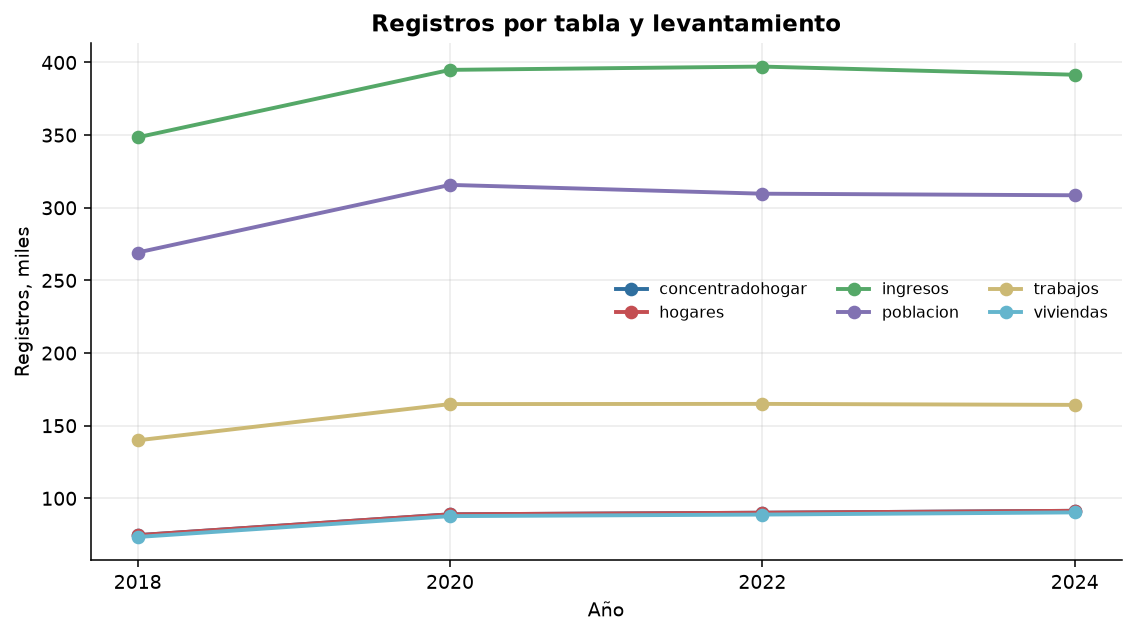

In [6]:
pivot_counts = conteos_anio.pivot(index="anio", columns="tabla", values="registros").sort_index()

fig, ax = plt.subplots(figsize=(9.5, 4.8))
for idx, column in enumerate(pivot_counts.columns):
    ax.plot(pivot_counts.index, pivot_counts[column] / 1_000, marker="o", linewidth=2, label=column, color=PALETTE[idx % len(PALETTE)])

ax.set_title("Registros por tabla y levantamiento")
ax.set_xlabel("Año")
ax.set_ylabel("Registros, miles")
ax.set_xticks(pivot_counts.index)
ax.legend(ncol=3, fontsize=8)
fig.savefig(FIG_DIR / "01_registros_por_tabla_anio.png", bbox_inches="tight")
display(fig)
plt.close(fig)

## 3. Geografía: integración válida, pero con cautela municipal

La geografía se integró a nivel municipal usando `ubica_geo = Clave de AGEE + Clave de AGEM`. El match es completo en `concentradohogar` y `viviendas`; aun así, para análisis municipal hay que revisar tamaño de muestra, porque tener municipio identificado no significa que todos los municipios tengan suficientes observaciones para inferencia.

In [7]:
geo_display = cobertura_geo.copy()
geo_display["registros"] = geo_display["registros"].map(format_int)
geo_display["ubica_geo_unicos"] = geo_display["ubica_geo_unicos"].map(format_int)
geo_display["pct_match"] = geo_display["pct_match"].map(format_pct)
geo_display["pct_sin_match"] = geo_display["pct_sin_match"].map(format_pct)
geo_display = geo_display[["tabla", "anio", "registros", "ubica_geo_unicos", "pct_match", "pct_sin_match"]]

display(geo_display)

tabla,anio,registros,ubica_geo_unicos,pct_match,pct_sin_match
concentradohogar,2018,"74,647",996,100.0%,0.0%
concentradohogar,2020,"89,006","1,090",100.0%,0.0%
concentradohogar,2022,"90,102","1,132",100.0%,0.0%
concentradohogar,2024,"91,414","1,112",100.0%,0.0%
viviendas,2018,"73,405",996,100.0%,0.0%
viviendas,2020,"87,754","1,090",100.0%,0.0%
viviendas,2022,"88,823","1,132",100.0%,0.0%
viviendas,2024,"90,324","1,112",100.0%,0.0%


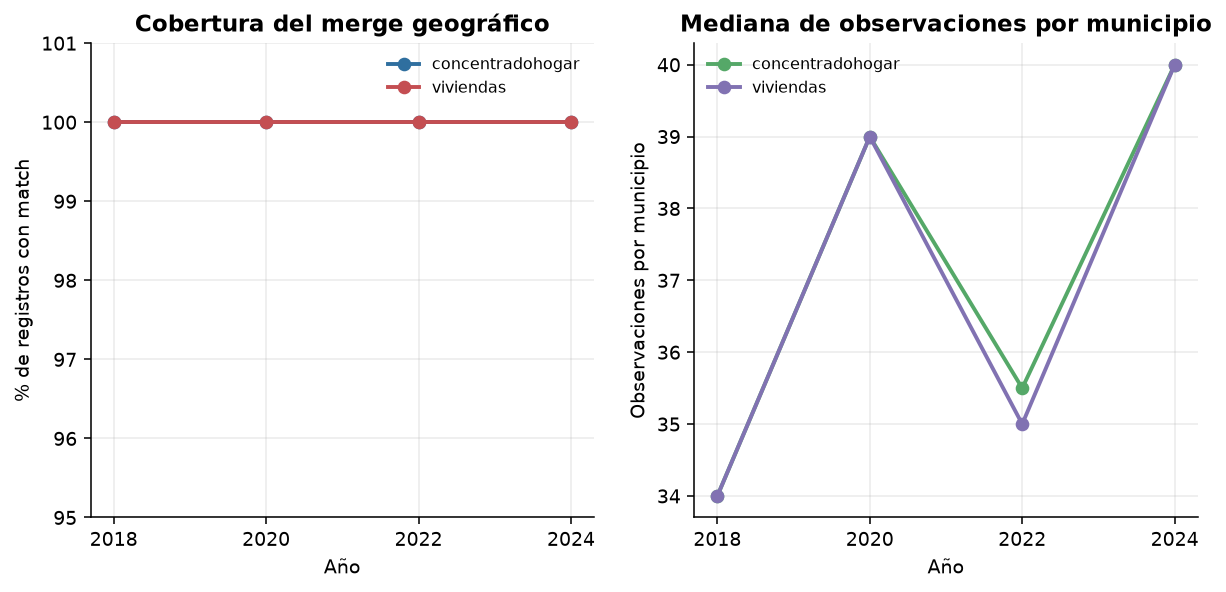

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.4))

for idx, (table, group) in enumerate(cobertura_geo.groupby("tabla")):
    axes[0].plot(group["anio"], group["pct_match"], marker="o", linewidth=2, label=table, color=PALETTE[idx])
axes[0].set_title("Cobertura del merge geografico")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("% de registros con match")
axes[0].set_ylim(95, 101)
axes[0].set_xticks(sorted(cobertura_geo["anio"].unique()))
axes[0].legend(fontsize=8)

for idx, (table, group) in enumerate(obs_mun.groupby("tabla")):
    axes[1].plot(group["anio"], group["mediana"], marker="o", linewidth=2, label=table, color=PALETTE[idx + 2])
axes[1].set_title("Mediana de observaciones por municipio")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Observaciones por municipio")
axes[1].set_xticks(sorted(obs_mun["anio"].unique()))
axes[1].legend(fontsize=8)

fig.savefig(FIG_DIR / "02_geografia_cobertura_municipios.png", bbox_inches="tight")
display(fig)
plt.close(fig)

In [9]:
obs_display = obs_mun[["tabla", "anio", "municipios_observados", "min", "mediana", "p90", "max", "lt_20", "lt_50"]].copy()
for col in ["municipios_observados", "min", "max", "lt_20", "lt_50"]:
    obs_display[col] = obs_display[col].map(format_int)
for col in ["mediana", "p90"]:
    obs_display[col] = obs_display[col].map(lambda x: f"{float(x):,.1f}")

display(obs_display)

tabla,anio,municipios_observados,min,mediana,p90,max,lt_20,lt_50
concentradohogar,2018,996,4,34.0,146.5,"1,384",124,655
concentradohogar,2020,"1,090",4,39.0,171.1,"1,500",180,699
concentradohogar,2022,"1,132",3,35.5,169.5,"1,544",212,740
concentradohogar,2024,"1,112",2,40.0,177.9,"1,689",126,719
viviendas,2018,996,4,34.0,144.0,"1,358",131,662
viviendas,2020,"1,090",4,39.0,168.1,"1,477",192,705
viviendas,2022,"1,132",3,35.0,166.6,"1,525",228,741
viviendas,2024,"1,112",2,40.0,176.9,"1,670",132,720


## 4. Decodificación: pasar de códigos a lectura sustantiva

Esta etapa es clave para una tesina: en vez de interpretar `1`, `2` o `03`, el notebook puede trabajar con etiquetas. La validación actual indica que las variables decodificadas no tienen códigos observados sin mapping; lo pendiente se concentra en variables que conviene revisar manualmente antes de usarlas.

In [10]:
desc_por_tabla = archivos_r3[["tabla", "columnas_desc_creadas"]].sort_values("columnas_desc_creadas", ascending=False)
estabilidad_counts = matriz_estabilidad["estado"].value_counts().rename_axis("estado").reset_index(name="variables")

display(desc_por_tabla)
display(estabilidad_counts)

tabla,columnas_desc_creadas
poblacion,127
trabajos,47
hogares,43
viviendas,34
ingresos,7
concentradohogar,5


estado,variables
no disponible en todos los años,395
estable,207
categorías diferentes,86


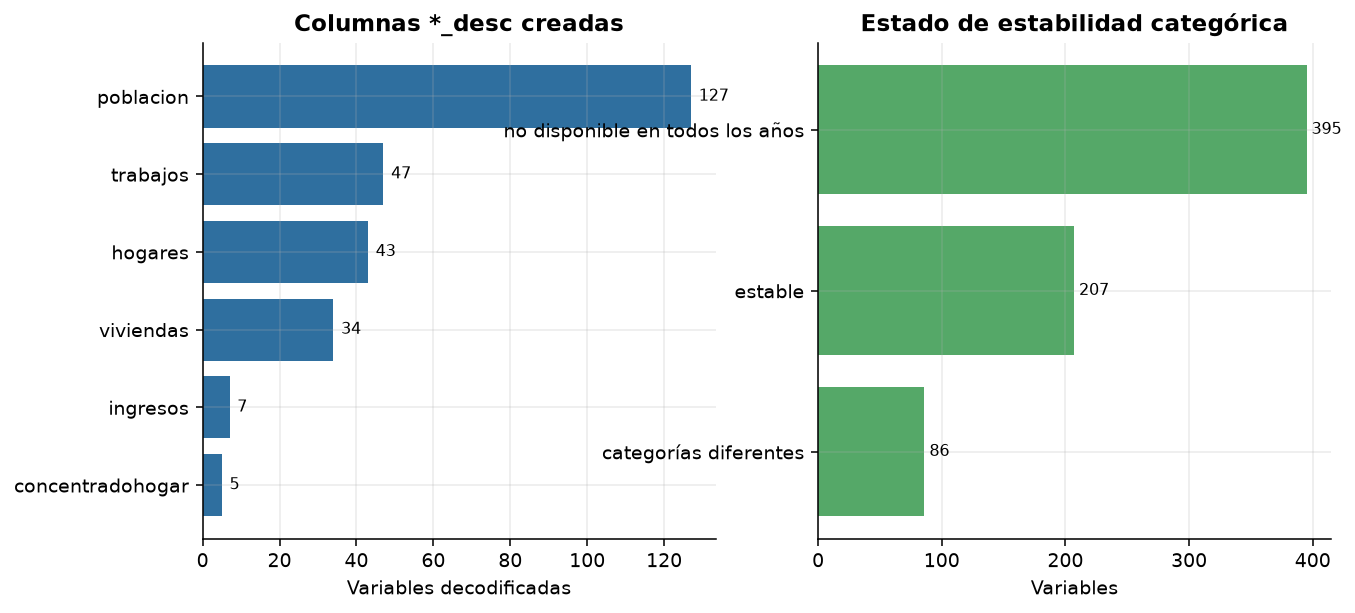

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.6))

axes[0].barh(desc_por_tabla["tabla"], desc_por_tabla["columnas_desc_creadas"], color=PALETTE[0])
axes[0].invert_yaxis()
axes[0].set_title("Columnas *_desc creadas")
axes[0].set_xlabel("Variables decodificadas")
axes[0].set_ylabel("")
for y, value in enumerate(desc_por_tabla["columnas_desc_creadas"]):
    axes[0].text(value + 2, y, format_int(value), va="center", fontsize=8)

axes[1].barh(estabilidad_counts["estado"], estabilidad_counts["variables"], color=PALETTE[2])
axes[1].invert_yaxis()
axes[1].set_title("Estado de estabilidad categorica")
axes[1].set_xlabel("Variables")
axes[1].set_ylabel("")
for y, value in enumerate(estabilidad_counts["variables"]):
    axes[1].text(value + 4, y, format_int(value), va="center", fontsize=8)

fig.savefig(FIG_DIR / "03_decodificacion_estabilidad.png", bbox_inches="tight")
display(fig)
plt.close(fig)

In [12]:
revision_prioritaria_display = muestra_prioritaria[[
    "anio", "variable", "observados", "documentados", "mapeados", "sin_mapping", "normalizaciones_para_mapping", "tiene_mapping"
]].head(16).copy()

for col in ["observados", "documentados", "mapeados", "sin_mapping"]:
    revision_prioritaria_display[col] = revision_prioritaria_display[col].map(format_int)

display(revision_prioritaria_display)

anio,variable,observados,documentados,mapeados,sin_mapping,normalizaciones_para_mapping,tiene_mapping
2018,alfabetism,2,2,2,0,NaN,True
2018,asis_esc,2,2,2,0,NaN,True
2018,edo_conyug,6,6,6,0,NaN,True
2018,etnia,2,2,2,0,NaN,True
2018,hablaind,2,2,2,0,NaN,True
2018,lenguaind,84,0,0,84,NaN,False
2018,nivelaprob,10,10,10,0,NaN,True
2018,parentesco,34,63,34,0,NaN,True
2018,residencia,34,34,34,0,NaN,True
2018,sexo,2,2,2,0,NaN,True


In [13]:
def parse_pending_count(text):
    if not isinstance(text, str):
        return np.nan
    match = re.search(r"por ([\d,]+) c[oó]digos", text)
    if not match:
        return np.nan
    return float(match.group(1).replace(",", ""))


manual = variables_manual.copy()
manual["codigos_sin_mapping"] = manual["observacion"].map(parse_pending_count)
manual_top = (
    manual.dropna(subset=["codigos_sin_mapping"])
    .sort_values("codigos_sin_mapping", ascending=False)
    .head(12)
    [["tabla", "variable", "estable_4_anios", "codigos_sin_mapping", "observacion"]]
)

manual_top_display = manual_top.copy()
manual_top_display["codigos_sin_mapping"] = manual_top_display["codigos_sin_mapping"].map(format_int)
manual_top_display["observacion"] = manual_top_display["observacion"].str.replace("Mapping extraido, pero ", "", regex=False)

display(manual_top_display)

tabla,variable,estable_4_anios,codigos_sin_mapping,observacion
hogares,anio_maqui,estable,280,no se decodifica por 280 códigos sin mapping.
hogares,anio_estuf,estable,263,no se decodifica por 263 códigos sin mapping.
poblacion,prob_anio,estable,238,no se decodifica por 238 códigos sin mapping.
hogares,anio_refri,estable,234,no se decodifica por 234 códigos sin mapping.
hogares,anio_licua,estable,232,no se decodifica por 232 códigos sin mapping.
hogares,anio_bici,estable,230,no se decodifica por 230 códigos sin mapping.
hogares,anio_radio,estable,226,no se decodifica por 226 códigos sin mapping.
hogares,anio_planc,estable,225,no se decodifica por 225 códigos sin mapping.
hogares,anio_pickup,no disponible en todos los años,215,no se decodifica por 215 códigos sin mapping.
hogares,anio_auto,estable,213,no se decodifica por 213 códigos sin mapping.


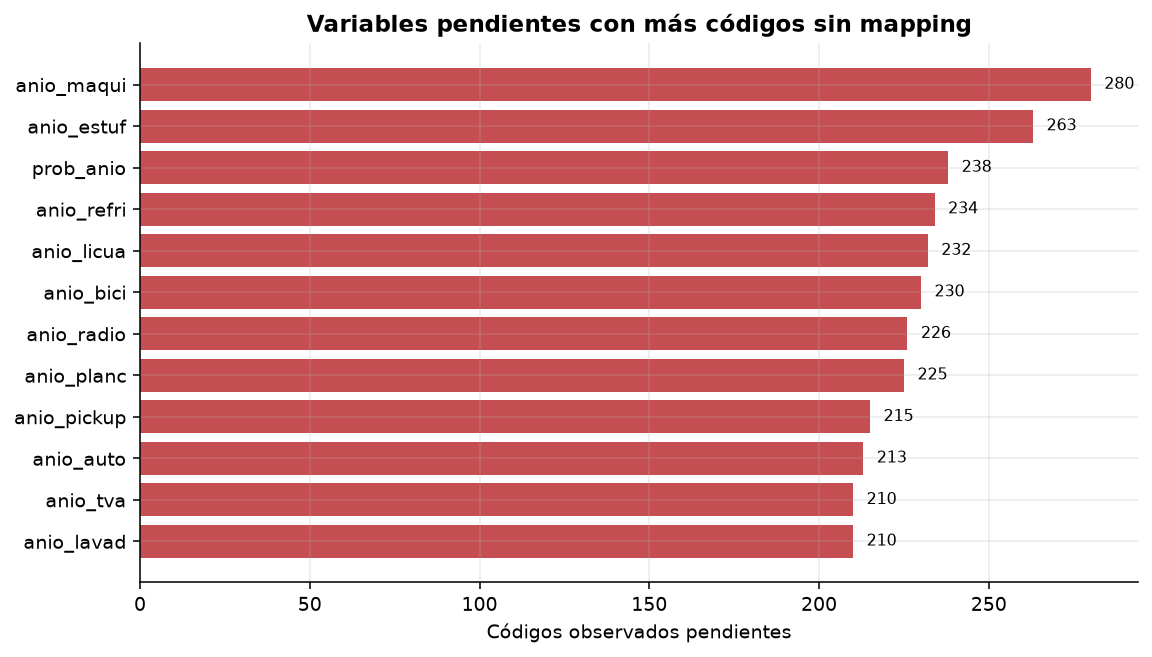

In [14]:
plot_manual = manual_top.sort_values("codigos_sin_mapping")

fig, ax = plt.subplots(figsize=(9.2, 5.0))
ax.barh(plot_manual["variable"], plot_manual["codigos_sin_mapping"], color=PALETTE[1])
ax.set_title("Variables pendientes con mas codigos sin mapping")
ax.set_xlabel("Codigos observados pendientes")
ax.set_ylabel("")
for y, value in enumerate(plot_manual["codigos_sin_mapping"]):
    ax.text(value + 4, y, format_int(value), va="center", fontsize=8)

fig.savefig(FIG_DIR / "04_pendientes_mapping.png", bbox_inches="tight")
display(fig)
plt.close(fig)

## 5. Primeras lecturas sustantivas

Estas gráficas son descriptivas y sirven para orientar el tema de tesina. Los ingresos se muestran en pesos nominales trimestrales; antes de comparar bienestar real entre años falta deflactar. Aun así, la forma de las series ayuda a revisar consistencia y a explicar por qué conviene trabajar con medianas y cuantiles.

In [15]:
concentrado = pd.read_csv(
    REV3 / "concentradohogar_decodificada_2018_2024.csv.gz",
    usecols=["anio", "ing_cor", "ingtrab", "tot_integ", "tam_loc_desc", "est_socio_desc"],
    low_memory=False,
)

for col in ["ing_cor", "ingtrab", "tot_integ"]:
    concentrado[col] = pd.to_numeric(concentrado[col], errors="coerce")

ingreso_resumen = (
    concentrado.groupby("anio")
    .agg(
        hogares=("ingtrab", "size"),
        mediana_ing_cor=("ing_cor", "median"),
        mediana_ingtrab=("ingtrab", "median"),
        p25_ingtrab=("ingtrab", lambda s: s.quantile(0.25)),
        p75_ingtrab=("ingtrab", lambda s: s.quantile(0.75)),
        mediana_integrantes=("tot_integ", "median"),
    )
    .reset_index()
)

ingreso_display = ingreso_resumen.copy()
ingreso_display["hogares"] = ingreso_display["hogares"].map(format_int)
for col in ["mediana_ing_cor", "mediana_ingtrab", "p25_ingtrab", "p75_ingtrab"]:
    ingreso_display[col] = ingreso_display[col].map(format_money)
ingreso_display["mediana_integrantes"] = ingreso_display["mediana_integrantes"].map(lambda x: f"{float(x):,.1f}")

display(ingreso_display)

anio,hogares,mediana_ing_cor,mediana_ingtrab,p25_ingtrab,p75_ingtrab,mediana_integrantes
2018,"74,647","$33,573","$22,293","$9,387","$40,940",3.0
2020,"89,006","$35,172","$22,131","$8,200","$41,365",3.0
2022,"90,102","$46,074","$29,899","$12,171","$54,328",3.0
2024,"91,414","$55,666","$36,411","$14,583","$65,010",3.0


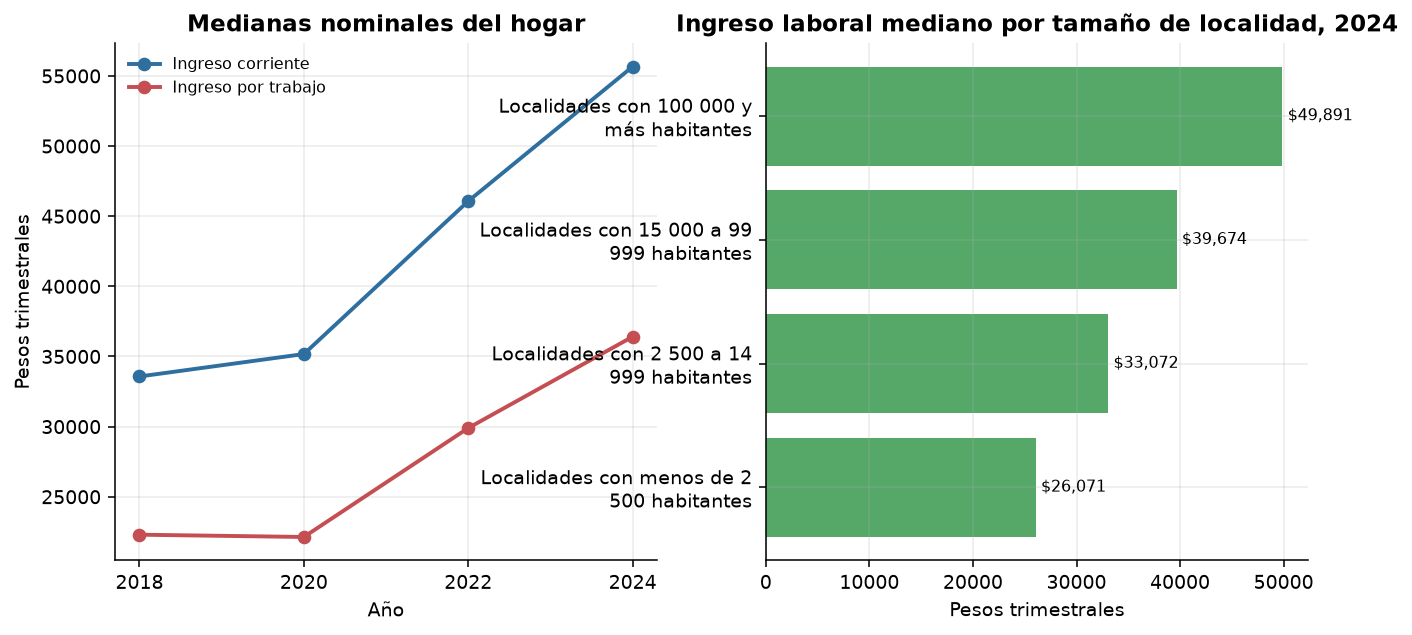

In [16]:
from textwrap import fill

tamloc_2024 = (
    concentrado.loc[concentrado["anio"] == 2024]
    .groupby("tam_loc_desc", dropna=False)["ingtrab"]
    .median()
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].plot(ingreso_resumen["anio"], ingreso_resumen["mediana_ing_cor"], marker="o", linewidth=2, label="Ingreso corriente", color=PALETTE[0])
axes[0].plot(ingreso_resumen["anio"], ingreso_resumen["mediana_ingtrab"], marker="o", linewidth=2, label="Ingreso por trabajo", color=PALETTE[1])
axes[0].set_title("Medianas nominales del hogar")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Pesos trimestrales")
axes[0].set_xticks(ingreso_resumen["anio"])
axes[0].legend(fontsize=8)

wrapped_labels = [fill(str(label), 28) for label in tamloc_2024.index]
axes[1].barh(wrapped_labels, tamloc_2024.values, color=PALETTE[2])
axes[1].set_title("Ingreso laboral mediano por tamano de localidad, 2024")
axes[1].set_xlabel("Pesos trimestrales")
axes[1].set_ylabel("")
for y, value in enumerate(tamloc_2024.values):
    axes[1].text(value + max(tamloc_2024.values) * 0.01, y, format_money(value), va="center", fontsize=8)

fig.savefig(FIG_DIR / "05_ingresos_descriptivos.png", bbox_inches="tight")
display(fig)
plt.close(fig)

In [17]:
poblacion = pd.read_csv(
    REV3 / "poblacion_decodificada_2018_2024.csv.gz",
    usecols=["anio", "edad", "sexo_desc", "nivelaprob_desc"],
    low_memory=False,
)
poblacion["edad"] = pd.to_numeric(poblacion["edad"], errors="coerce")

edad_resumen = (
    poblacion.groupby("anio")["edad"]
    .agg(personas="count", media="mean", mediana="median", p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75))
    .reset_index()
)

edad_display = edad_resumen.copy()
edad_display["personas"] = edad_display["personas"].map(format_int)
for col in ["media", "mediana", "p25", "p75"]:
    edad_display[col] = edad_display[col].map(lambda x: f"{float(x):,.1f}")

display(edad_display)

anio,personas,media,mediana,p25,p75
2018,"269,206",31.5,28.0,14.0,47.0
2020,"315,743",32.8,30.0,15.0,49.0
2022,"309,684",33.3,30.0,15.0,50.0
2024,"308,598",33.9,32.0,15.0,50.0


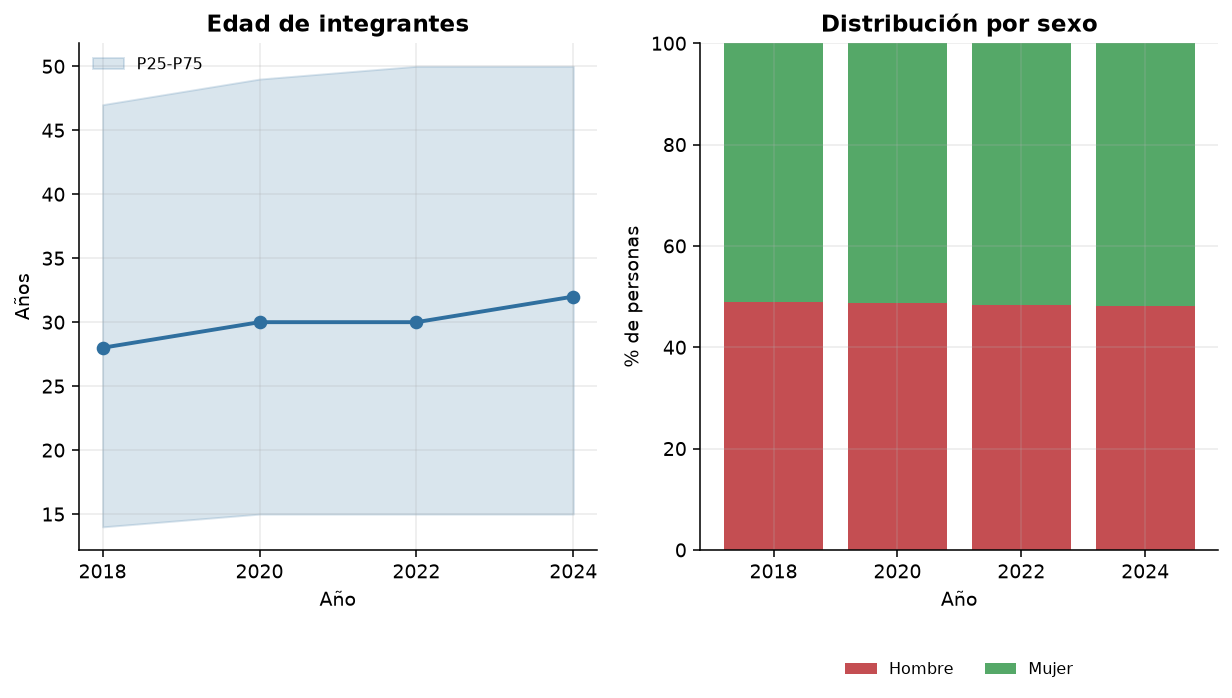

In [18]:
sexo_counts = poblacion.groupby(["anio", "sexo_desc"]).size().unstack(fill_value=0).sort_index()
sexo_pct = sexo_counts.div(sexo_counts.sum(axis=1), axis=0) * 100

nivel_2024 = (
    poblacion.loc[poblacion["anio"] == 2024, "nivelaprob_desc"]
    .fillna("Sin dato")
    .value_counts()
    .head(8)
    .rename_axis("nivel aprobado")
    .reset_index(name="personas")
)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.7))
axes[0].plot(edad_resumen["anio"], edad_resumen["mediana"], marker="o", linewidth=2, color=PALETTE[0])
axes[0].fill_between(edad_resumen["anio"], edad_resumen["p25"], edad_resumen["p75"], alpha=0.18, color=PALETTE[0], label="P25-P75")
axes[0].set_title("Edad de integrantes")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Años")
axes[0].set_xticks(edad_resumen["anio"])
axes[0].legend(fontsize=8)

bottom = np.zeros(len(sexo_pct))
for idx, col in enumerate(sexo_pct.columns):
    values = sexo_pct[col].values
    axes[1].bar(sexo_pct.index.astype(str), values, bottom=bottom, label=str(col), color=PALETTE[idx + 1])
    bottom += values
axes[1].set_title("Distribucion por sexo")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("% de personas")
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=2)

fig.savefig(FIG_DIR / "06_poblacion_descriptivos.png", bbox_inches="tight")
display(fig)
plt.close(fig)

In [19]:
nivel_2024_display = nivel_2024.copy()
nivel_2024_display["personas"] = nivel_2024_display["personas"].map(format_int)
display(nivel_2024_display)

nivel aprobado,personas
Primaria,"86,446"
Secundaria,"79,810"
Preparatoria o bachillerato,"53,445"
Licenciatura o Ingeniería (profesional),"38,737"
Ninguno,"16,324"
Preescolar o kínder,"12,727"
Sin dato,"10,645"
Estudios técnicos o comerciales,"5,881"
